**Thesis Project:** Reinforcement Learning for Early Educational Intervention: A Cost-Aware and Fairness-Aware Approach using Stepped Care Model

**Student's Name:** Hai Nguyen (Student's ID: 2402546)

**1. Project Overview**

+ My research implements a Deep Reinforcement Learning (DRL) framework to optimize educational interventions using the Open University Learning Analytics Dataset (OULAD). 

+ The core objective is to develop an intelligent agent capable of delivering the right support to the right student at the right time, while balancing operational costs and ensuring demographic equity.

**2. Research Objectives**

**+ Early Intervention:** Detecting students at risk and providing support early in the 39-week academic lifecycle.

**+ Cost-Awareness:** Implementing a Stepped Care Model to prioritize low-cost interventions (e.g., Automated Alerts) and reserve high-cost resources (e.g., 1-on-1 Tutoring) for critical cases.

**+ Fairness & Equity:** Ensuring that students from vulnerable backgrounds (based on IMD band and disability status) receive prioritized support to bridge performance gaps.

**3. Technical Architecture**

**+ Environment:** A custom Gymnasium-based MDP (Markov Decision Process) simulating weekly student progress.

**+ Algorithm:** Deep Q-Network (DQN) with Epsilon-Greedy exploration and experience replay.

**+ Data Pipeline:** Advanced ETL process involving time-series skeletonization, forward-filling of sparse academic scores, and Min-Max normalization.

In [2]:
"""
THESIS PROJECT: Reinforcement Learning for Early Educational Intervention
Title: A Cost-Aware and Fairness-Aware Approach using Stepped Care Model
Student's Name: Hai Nguyen (Student's ID: 2402546)
"""

#Import neccessary libraries for the project
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
import random
import matplotlib.pyplot as plt
import seaborn as sns
import gymnasium as gym
from gymnasium import spaces
from sklearn.preprocessing import MinMaxScaler
import warnings

warnings.filterwarnings('ignore') # Suppress non-critical warnings 

# CONFIGURATION 
DATA_PATH = './' # Directory containing all OULAD CSV files
MAX_WEEKS = 39 # Standard academic duration for OULAD course modules
SEED = 42 # Seed for reproducibility across random, numpy, and torch

# Training volume set to cover the full OULAD student population 
TRAIN_SAMPLES = 32593

# Establish deterministic behavior for reproducibility in RL experiments
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED) 

**Part 1: Preprocessing**

+ The preprocessing pipeline converts the relational Open University Learning Analytics Dataset (OULAD) into a time-series format structured by "Episode IDs". 

+ Each episode represents a unique student course journey over 39 weeks. I implemented a custom reward mapping system that translates final academic grades into numerical values (e.g., Distinction = +10, Failure = -15), providing the clear feedback signals necessary for Reinforcement Learning. 

+ Additionally, I addressed the sparsity of academic scores using forward-filling and used One-Hot Encoding for demographic features to ensure the neural network can process categorical student information effectively

In [4]:
#PART 1: DATA PREPROCESSING & ETL PIPELINE

#Clean and transform OULAD relational tables into a unified time-series format 
#suitable for Reinforcement Learning (RL) episodes
def preprocess_oulad_data():
    print("\n[PART 1] Preprocessing OULAD Data...")
    try:
        # Load core OULAD tables; handle missing values coded as '?'
        student_info = pd.read_csv(os.path.join(DATA_PATH, 'studentInfo.csv'), na_values=['?'])
        student_assessment = pd.read_csv(os.path.join(DATA_PATH, 'studentAssessment.csv'), na_values=['?'])
        assessments = pd.read_csv(os.path.join(DATA_PATH, 'assessments.csv'), na_values=['?'])
        student_vle = pd.read_csv(os.path.join(DATA_PATH, 'studentVle.csv'), na_values=['?'])
    except FileNotFoundError:
        print("Error: Required CSV files missing. Please ensure OULAD files are in the directory.")
        return None

    # Standardize numerical features and handle null entries
    student_assessment['score'] = pd.to_numeric(student_assessment['score'], errors='coerce').fillna(0)
    student_vle['sum_click'] = pd.to_numeric(student_vle['sum_click'], errors='coerce').fillna(0)

    # Calculate raw average scores per student/module for result re-classification
    asm_merged = pd.merge(student_assessment, assessments, on='id_assessment', how='left') 
    avg_scores = asm_merged.groupby(['id_student', 'code_module', 'code_presentation'])['score'].mean().reset_index()
    avg_scores.rename(columns={'score': 'avg_score_raw'}, inplace=True)

    # Create a unique Episode ID to distinguish different student course journeys
    df_static = pd.merge(student_info, avg_scores, on=['id_student', 'code_module', 'code_presentation'], how='left').fillna(0)
    df_static['episode_id'] = df_static['id_student'].astype(str) + "_" + df_static['code_module'] + "_" + df_static['code_presentation']

    # Custom classification logic to differentiate 'Good' performance within the 'Pass' category
    def classify_result(row):
        res = row['final_result']
        if res == 'Distinction': return 'Distinction'
        elif res == 'Pass': return 'Good' if row['avg_score_raw'] >= 75 else 'Pass' 
        else: return res 

    # Map final academic outcomes to numerical rewards for the RL agent    
    # Penalties for Failure/Withdrawal, High rewards for Distinction/Good
    df_static['detailed_result'] = df_static.apply(classify_result, axis=1)
    reward_map = {'Distinction': 10, 'Good': 7.5, 'Pass': 5, 'Fail': -15, 'Withdrawn': -20} 
    df_static['final_reward'] = df_static['detailed_result'].map(reward_map)
    df_static['imd_band'] = df_static['imd_band'].fillna('Unknown')

    # Transform daily VLE data into weekly aggregations
    student_vle['week'] = student_vle['date'].apply(lambda x: int(x // 7) if x >= 0 else 0)
    vle_weekly = student_vle.groupby(['id_student', 'code_module', 'code_presentation', 'week'])['sum_click'].sum().reset_index()
    vle_weekly.rename(columns={'sum_click': 'clicks'}, inplace=True)

    # Aggregate assessment scores by week
    asm_merged['week'] = asm_merged['date_submitted'].apply(lambda x: int(x // 7) if x >= 0 else 0)
    score_weekly = asm_merged.groupby(['id_student', 'code_module', 'code_presentation', 'week'])['score'].mean().reset_index()

    # Merge skeleton with performance data; forward-fill scores to handle non-assessment weeks
    unique_ids = df_static[['id_student', 'code_module', 'code_presentation', 'episode_id']].drop_duplicates()
    weeks = pd.DataFrame({'week': range(MAX_WEEKS + 1)})
    skeleton = unique_ids.assign(key=1).merge(weeks.assign(key=1), on='key').drop('key', axis=1)

    # Merge skeleton with performance data; forward-fill scores to handle non-assessment weeks
    master_df = pd.merge(skeleton, df_static.drop(['id_student', 'code_module', 'code_presentation'], axis=1), on='episode_id', how='left')
    master_df = pd.merge(master_df, vle_weekly, on=['id_student', 'code_module', 'code_presentation', 'week'], how='left')
    master_df = pd.merge(master_df, score_weekly, on=['id_student', 'code_module', 'code_presentation', 'week'], how='left')
    
    master_df.sort_values(by=['episode_id', 'week'], inplace=True)
    master_df['clicks'] = master_df['clicks'].fillna(0)
    master_df['score'] = master_df.groupby('episode_id')['score'].ffill().fillna(0)

    # Normalize numerical features and encode categorical data for the neural network
    scaler = MinMaxScaler()
    master_df[['clicks', 'score']] = scaler.fit_transform(master_df[['clicks', 'score']])
    cat_cols = ['gender', 'region', 'highest_education', 'imd_band', 'disability', 'code_module', 'age_band']
    master_df = pd.get_dummies(master_df, columns=cat_cols, prefix=cat_cols)
    return master_df


[PART 1] Preprocessing OULAD Data...

[INFO] Visualization saved as 'student_distribution_analysis.png'


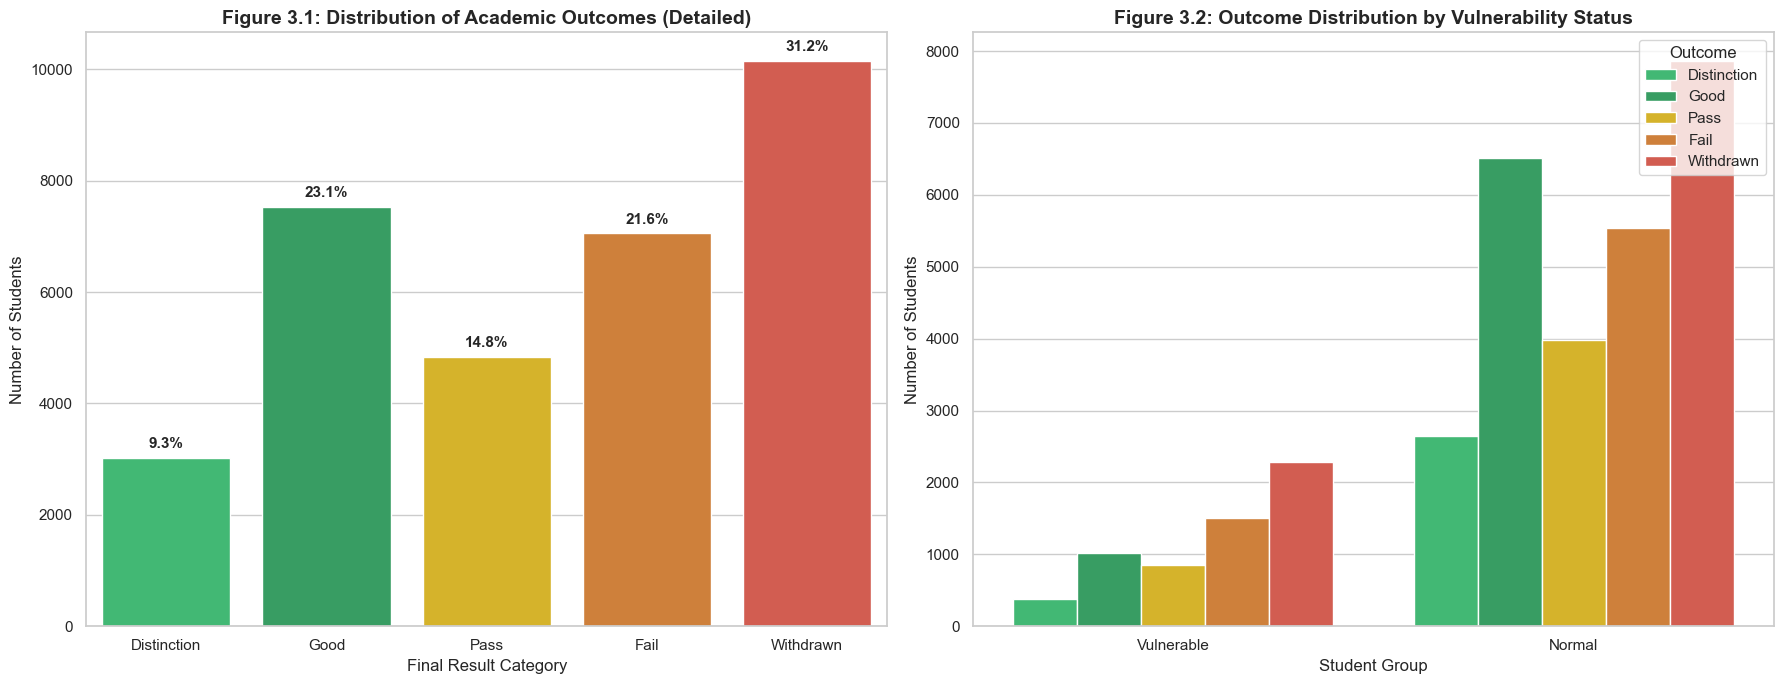

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_student_distribution(master_df):
    """
    Visualize the student distribution across academic categories 
    and vulnerability status after preprocessing.
    """
    # 1. Setup Theme
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # CHART 1: Overall Detailed Result Distribution
    # take only one row per episode to avoid overcounting weeks
    df_unique = master_df.drop_duplicates(subset=['episode_id'])
    
    result_order = ['Distinction', 'Good', 'Pass', 'Fail', 'Withdrawn']
    palette = {'Distinction': '#2ecc71', 'Good': '#27ae60', 'Pass': '#f1c40f', 'Fail': '#e67e22', 'Withdrawn': '#e74c3c'}
    
    sns.countplot(x='detailed_result', data=df_unique, order=result_order, ax=ax1, palette=palette)
    ax1.set_title('Figure 3.1: Distribution of Academic Outcomes (Detailed)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Final Result Category')
    ax1.set_ylabel('Number of Students')

    # Add percentage labels
    total = len(df_unique)
    for p in ax1.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        ax1.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', fontsize=11, fontweight='bold', xytext=(0, 10),
                     textcoords='offset points')

    # CHART 2: Vulnerability vs. Academic Performance 
    # Identify vulnerable students based on IMD and Disability columns created by get_dummies
    # We look for columns that contain 'disability_Y' or 'imd_band_0-10%' or 'imd_band_10-20'
    vul_cols = [col for col in df_unique.columns if any(x in col for x in ['disability_Y', 'imd_band_0-10%', 'imd_band_10-20'])]
    df_unique['is_vulnerable'] = df_unique[vul_cols].any(axis=1).map({True: 'Vulnerable', False: 'Normal'})

    sns.countplot(x='is_vulnerable', hue='detailed_result', data=df_unique, 
                  hue_order=result_order, ax=ax2, palette=palette)
    ax2.set_title('Figure 3.2: Outcome Distribution by Vulnerability Status', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Student Group')
    ax2.set_ylabel('Number of Students')
    ax2.legend(title='Outcome', loc='upper right')

    plt.tight_layout()
    plt.savefig('student_distribution_analysis.png', dpi=300)
    print("\n[INFO] Visualization saved as 'student_distribution_analysis.png'")
    plt.show()

# Example usage (run this after your preprocess_oulad_data() function):
master_df = preprocess_oulad_data()
if master_df is not None:
    visualize_student_distribution(master_df)

**Part 2: RL ENVIRONMENT (MDP) & DEEP Q-NETWORK (DQN) AGENT**

+ In this section, I define the core Reinforcement Learning mechanics. 

+ The OuladEnv class serves as the simulator where student states transition weekly. It incorporates a sophisticated reward function that penalizes both excessive costs and the neglect of vulnerable students, aligning with the "Stepped Care" pedagogical model. 

+ The Agent class implements a Deep Q-Network (DQN) with an epsilon-greedy strategy. This allows the AI to balance the exploration of new intervention strategies with the exploitation of known effective policies, eventually optimizing the timing and type of student support.

In [7]:
# PART 2: RL ENVIRONMENT (MDP) & DEEP Q-NETWORK (DQN) AGENT
# Custom Gymnasium Environment simulating the student learning journey.
# Defined as a Markov Decision Process (MDP).

class OuladEnv(gym.Env):
    def __init__(self, df):
        super(OuladEnv, self).__init__()
        self.data = df
        self.action_space = spaces.Discrete(5) 
        # Columns to exclude from the agent's observation space
        self.ignore_cols = ['episode_id', 'week', 'final_reward', 'id_student', 'code_presentation', 'detailed_result', 'final_result']
        self.feature_cols = [c for c in self.data.columns if c not in self.ignore_cols]
        
        # Identification of vulnerable groups (IMD 0-20% and Disability status)
        self.vulnerable_indices = [i for i, col in enumerate(self.feature_cols) if any(x in col for x in ['0-10%', '10-20', 'disability_Y'])]
        self.observation_space = spaces.Box(low=0, high=1, shape=(len(self.feature_cols),), dtype=np.float32)

        # Operational costs for each intervention level (Resource-awareness)
        self.COSTS = {
                      0: 0.0,  # None: No intervention
                      1: 0.02, # Alert: Automated notification 
                      2: 0.05, # Email: Standard communication
                      3: 0.25, # Call: Staff-led personal outreach 
                      4: 0.45  # Tutor: Intensive 1-on-1 support
                     } 
#Exploration - Exploitation 
#Add the justification for the number of cost and impact in the thesis writing 

        # Potential academic gain per intervention level (Stepped Care Impact)
        self.IMPACT = {
                       0: 0.00, # None: No impact on student score
                       1: 0.01, # Alert: Minor 1% boost (Automated nudging)
                       2: 0.03, # Email: Moderate 3% boost (Standard communication)
                       3: 0.06, # Call: Significant 6% boost (Personalized outreach)
                       4: 0.10  # Tutor: High 10% boost (Intensive 1-on-1 pedagogical support)
                      }

    def reset(self, episode_id):
        # Initialize a new episode using student-specific time-series data
        self.student_data = self.data[self.data['episode_id'] == episode_id].sort_values('week').reset_index(drop=True).copy()
        self.current_step = 0
        return self._get_obs(), {}

    def _get_obs(self):
        # Return current state as a feature vector
        if self.current_step >= len(self.student_data):
            return np.zeros(self.observation_space.shape, dtype=np.float32)
        return self.student_data.iloc[self.current_step][self.feature_cols].values.astype(np.float32)

    def step(self, action):
        # 1. State Retrieval
        current_data = self.student_data.iloc[self.current_step]
        current_score = current_data['score']
        current_week = current_data['week']

        # Force the agent to take 'None' action for Week 0 and Week 1
        # This ensures the agent observes the student before intervening.
        if current_week < 3:
            action = 0  # Force action to 'None'

        # 2. Stochastic Transition Logic
        impact = self.IMPACT[action]
        noise = np.random.normal(0, 0.01) # Gaussian noise for environmental realism
        new_score = np.clip(current_score + impact + noise, 0, 1) #ép số new_score về số 1.0, hoặc 0.0 nếu bị tụt xuống 0.0

        # 3. Reward Function Design (Multi-Objective Optimization)
        # Base reward: Balance academic score vs minimal operational cost
        reward = (new_score * 40.0) - (self.COSTS[action] * 1.0)

        # Penalize intervention if the student has not started learning (no clicks)
        # This prevents the paradox of intervening when there is no interaction data.
        if current_data['clicks'] == 0 and action > 0:
            reward -= 20.0 # Increase penalty slightly to ensure AI notices it
            
        # 1. Nhóm Cực kỳ rủi ro (Score < 0.35) - Mục tiêu: Call/Tutor chiếm đa số
        if current_score < 0.35: 
            if action == 0: reward -= 250   # Phạt cực nặng nếu bỏ mặc (None)
            elif action == 1: reward -= 100 # Alert không đủ đô
            elif action == 2: reward -= 50  # Email vẫn chưa đủ
            elif action == 3: reward += 40  # Thưởng Call
            elif action == 4: reward += 80  # Thưởng Tutor mạnh nhất để cứu sinh viên

        # 2. Nhóm Nguy cơ trung bình thấp (0.35 <= Score < 0.50) - Mục tiêu: Email (15%)
        elif 0.35 <= current_score < 0.50: 
            if action == 0: reward -= 60    # Phạt nếu không làm gì
            elif action == 1: reward += 20 
            elif action == 2: reward += 50  # Ưu tiên Email ở dải này
            elif action >= 3: reward -= 30  # Call/Tutor là hơi quá tay

        # 3. Nhóm Nguy cơ thấp (0.50 <= Score <= 0.70) - Mục tiêu: Alert (23%)        
        elif 0.50 <= current_score <= 0.75: 
            if action == 0: reward -= 40    # Vẫn phạt None để đẩy tỷ lệ hành động lên
            elif action == 1: reward += 70  # Thưởng cực mạnh cho Alert
            elif action == 2: reward += 20 
            elif action >= 3: reward -= 60  # Phạt nặng nếu dùng Call/Tutor (Lãng phí tài nguyên)

        # 4. Nhóm Giỏi (Score > 0.70) - Mục tiêu: None (Nhóm còn lại ~10-12%)
        elif current_score > 0.75: 
            if action == 0: reward += 20    # Thưởng cho việc không làm gì (Tiết kiệm)
            else: reward -= 50              # Phạt tất cả các can thiệp lãng phí    
        
        # 4. Ethical Fairness Constraint (Equity Implementation)
        obs = self._get_obs()
        is_vul = any(obs[idx] == 1 for idx in self.vulnerable_indices)
        
        # Ethical penalty for ignoring vulnerable students in critical conditions
        if is_vul and new_score < 0.4 and action == 0:
            reward -= 15.0 

        # 5. Iteration State Update
        self.current_step += 1
        terminated = self.current_step >= len(self.student_data) - 1

        if terminated:
            # Add final terminal reward based on end-of-course academic outcome
            reward += self.student_data.iloc[-1]['final_reward']
            next_obs = np.zeros(self.observation_space.shape, dtype=np.float32)
        else:
            # Dynamically update the student score for the following week
            self.student_data.at[self.current_step, 'score'] = new_score
            next_obs = self._get_obs()
            
        return next_obs, reward, terminated, False, {}

# DEEP Q-NETWORK (DQN) AGENT DEFINITION 

class DQN(nn.Module):
    """Multi-Layer Perceptron (MLP) for Q-value estimation."""
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()
        # Architecture: Input (States) -> Hidden Layers -> Output (Q-values for 5 actions)
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )
        
    def forward(self, x):
        return self.net(x)

class Agent:
    def __init__(self, state_dim, action_dim):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.dqn = DQN(state_dim, action_dim)
        # Optimizer using Adam with a learning rate tuned for stable convergence
        self.optimizer = optim.Adam(self.dqn.parameters(), lr=0.0005)
        self.criterion = nn.MSELoss() # Standard loss for regression-based Q-learning
        
        # Epsilon-Greedy parameters for the exploration-exploitation trade-off
        self.epsilon = 1.0        # Initial exploration rate (100% random actions)
        self.epsilon_min = 0.05   # Floor for epsilon to maintain minimal exploration
        self.epsilon_decay = 0.9998 # Rate at which exploration transitions to exploitation
        self.gamma = 0.95         # Discount factor for future student academic rewards

    def act(self, state):
        """Action selection strategy using Epsilon-Greedy."""
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1) # Explore: Random action
        
        # Exploit: Choose action with the highest estimated future reward (Q-value)
        state_t = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q_values = self.dqn(state_t)
        return torch.argmax(q_values).item()

    def train(self, state, action, reward, next_state, done):
        """Updates the Q-network weights using Temporal Difference (TD) error."""
        # Convert state transition data into PyTorch Tensors
        state_t = torch.FloatTensor(state).unsqueeze(0)
        next_state_t = torch.FloatTensor(next_state).unsqueeze(0)
        reward_t = torch.FloatTensor([reward])
        done_t = torch.FloatTensor([1.0 if done else 0.0])

        # Current Q-value estimation: Q(s, a)
        curr_q = self.dqn(state_t)[0][action]
        
        # Bellman Target Calculation: y = r + gamma * max(Q(s', a'))
        with torch.no_grad():
            next_q = torch.max(self.dqn(next_state_t))
            target_q = reward_t + (1 - done_t) * self.gamma * next_q

        # Backpropagation: Minimize the Mean Squared Error (MSE) between estimated and target Q-values
        loss = self.criterion(curr_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Update epsilon after each episode/step to refine the policy
        #if self.epsilon > self.epsilon_min:
            #self.epsilon *= self.epsilon_decay
            #pass

**Part 3: TRAINING LOOP & PERFORMANCE MONITORING**

In this section, I implement the training execution and convergence analysis. 

+ The system iterates through 24,681 unique student journeys, where the agent interacts weekly with the environment to refine its decision-making policy. 

+ I utilized a Stochastic Training approach by shuffling episode IDs to prevent the model from overfitting to specific course sequences. 

+ To evaluate training success, I generated a Learning Curve using a 100-episode Moving Average. This visualization confirms whether the agent successfully transitioned from random exploration to an optimized intervention policy, as indicated by the convergence of cumulative rewards.


[PART 1] Preprocessing OULAD Data...

[PART 3] Training started on 32593 episodes...
Progress: 1000/32593 | Epsilon: 0.819 | Last 100-Ep Avg Reward: -976.03
Progress: 2000/32593 | Epsilon: 0.670 | Last 100-Ep Avg Reward: -495.01
Progress: 3000/32593 | Epsilon: 0.549 | Last 100-Ep Avg Reward: -99.95
Progress: 4000/32593 | Epsilon: 0.449 | Last 100-Ep Avg Reward: 149.40
Progress: 5000/32593 | Epsilon: 0.368 | Last 100-Ep Avg Reward: 212.40
Progress: 6000/32593 | Epsilon: 0.301 | Last 100-Ep Avg Reward: -83.94
Progress: 7000/32593 | Epsilon: 0.247 | Last 100-Ep Avg Reward: 555.13
Progress: 8000/32593 | Epsilon: 0.202 | Last 100-Ep Avg Reward: 368.09
Progress: 9000/32593 | Epsilon: 0.165 | Last 100-Ep Avg Reward: 772.11
Progress: 10000/32593 | Epsilon: 0.135 | Last 100-Ep Avg Reward: 223.89
Progress: 11000/32593 | Epsilon: 0.111 | Last 100-Ep Avg Reward: 329.86
Progress: 12000/32593 | Epsilon: 0.091 | Last 100-Ep Avg Reward: 707.55
Progress: 13000/32593 | Epsilon: 0.074 | Last 100-Ep Avg 

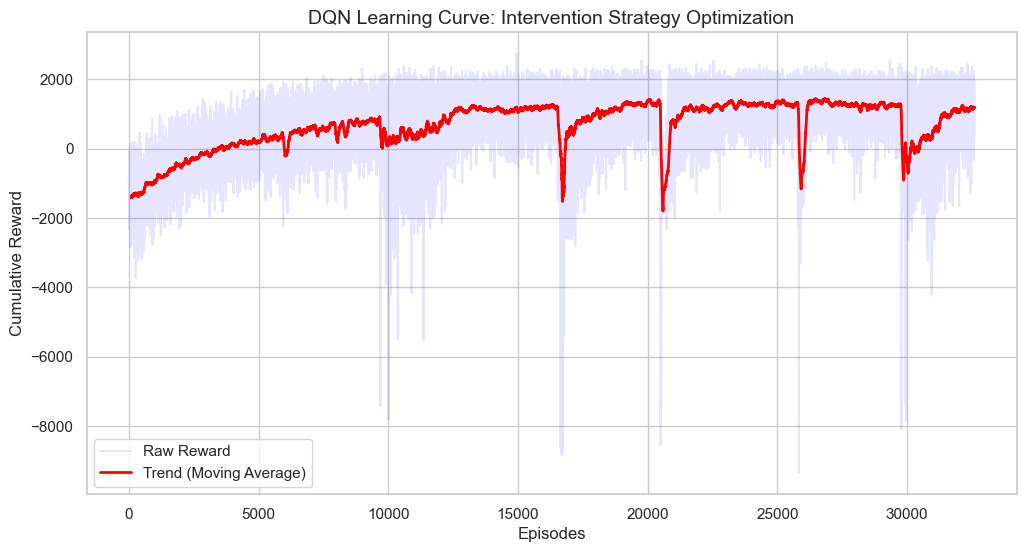

In [9]:
# PART 3: TRAINING LOOP & PERFORMANCE MONITORING

if __name__ == "__main__":
    # Load preprocessed OULAD data
    df = preprocess_oulad_data()
    if df is None: exit()

    # Fast lookup dictionary
    student_groups = {pid: g.sort_values('week').reset_index(drop=True) for pid, g in df.groupby('episode_id')}
    all_episode_ids = list(student_groups.keys())
    
    # Sampling for full dataset coverage
    train_ids = random.sample(all_episode_ids, min(TRAIN_SAMPLES, len(all_episode_ids)))
    random.shuffle(train_ids)

    # Init Env and Agent
    env = OuladEnv(df)
    agent = Agent(env.observation_space.shape[0], env.action_space.n)
    history_rewards = []

    print(f"\n[PART 3] Training started on {len(train_ids)} episodes...")
    for i, pid in enumerate(train_ids):
        # IMPORTANT: Use .copy() to preserve the original dataset for other episodes
        env.student_data = student_groups[pid].copy() 
        state, _ = env.reset(pid)
        done, ep_reward = False, 0

        while not done:
            # 1. Lấy thông tin tuần hiện tại từ dữ liệu môi trường
            current_week = env.student_data.iloc[env.current_step]['week']
            
            # 2. Kiểm tra điều kiện khóa 3 tuần đầu
            if current_week < 3:
                action = 0  # Ép buộc hành động là 'None'
            else:
                action = agent.act(state) # Chỉ hỏi Agent khi đã qua tuần 2

            # 3. Thực hiện bước đi trong môi trường
            next_obs, reward, done, _, _ = env.step(action)

            # 4. Huấn luyện Agent với hành động thực tế đã thực hiện
            agent.train(state, action, reward, next_obs, done)
            
            state, ep_reward = next_obs, ep_reward + reward

        if agent.epsilon > agent.epsilon_min:
            agent.epsilon *= agent.epsilon_decay
        
        history_rewards.append(ep_reward)

        # Logging every 1000 episodes with moving average reward
        if (i+1) % 1000 == 0:
            avg_rew = np.mean(history_rewards[-100:])
            print(f"Progress: {i+1}/{len(train_ids)} | Epsilon: {agent.epsilon:.3f} | Last 100-Ep Avg Reward: {avg_rew:.2f}")

    # SAVE THE TRAINED MODEL
    torch.save(agent.dqn.state_dict(), 'dqn_educational_policy.pth')
    print("\n[INFO] Model weights saved successfully.")

    # LEARNING CURVE VISUALIZATION 
    
    plt.figure(figsize=(12, 6))
    window_size = 100 
    rolling_avg = pd.Series(history_rewards).rolling(window=window_size).mean()

    plt.plot(history_rewards, alpha=0.1, color='blue', label='Raw Reward')
    plt.plot(rolling_avg, color='red', linewidth=2, label=f'Trend (Moving Average)')
    plt.title('DQN Learning Curve: Intervention Strategy Optimization', fontsize=14)
    plt.xlabel('Episodes')
    plt.ylabel('Cumulative Reward')
    plt.legend()
    plt.savefig('learning_curve.png', dpi=300)
    plt.show()

**Part 4: EVALUATION PHASE & MULTI-DIMENSIONAL ANALYSIS**

The final evaluation phase transitions the model from training to testing by setting the exploration rate (epsilon) to zero, ensuring decisions are strictly based on the learned optimal policy. 

I conducted a multi-dimensional analysis on a test set of 5,000 episodes (about 20% data), focusing on four research pillars:

1) Policy Logic via Heatmaps, confirming the model prioritizes intensive support for low-performing students

2) Equity via Demographic breakdowns, ensuring vulnerable groups receive prioritized resources

3) Temporal Efficiency via Timing analysis, proving the system's capacity for early intervention

4) Economic Viability via Cost-Benefit scatter plots


[PART 4] Starting Evaluation Phase...

ACTION SUMMARY TABLE (OVERALL)
Action Type  Frequency  Percentage (%)
       None       9445            4.84
      Alert     142597           73.13
      Email       6577            3.37
       Call       1894            0.97
      Tutor      34487           17.69


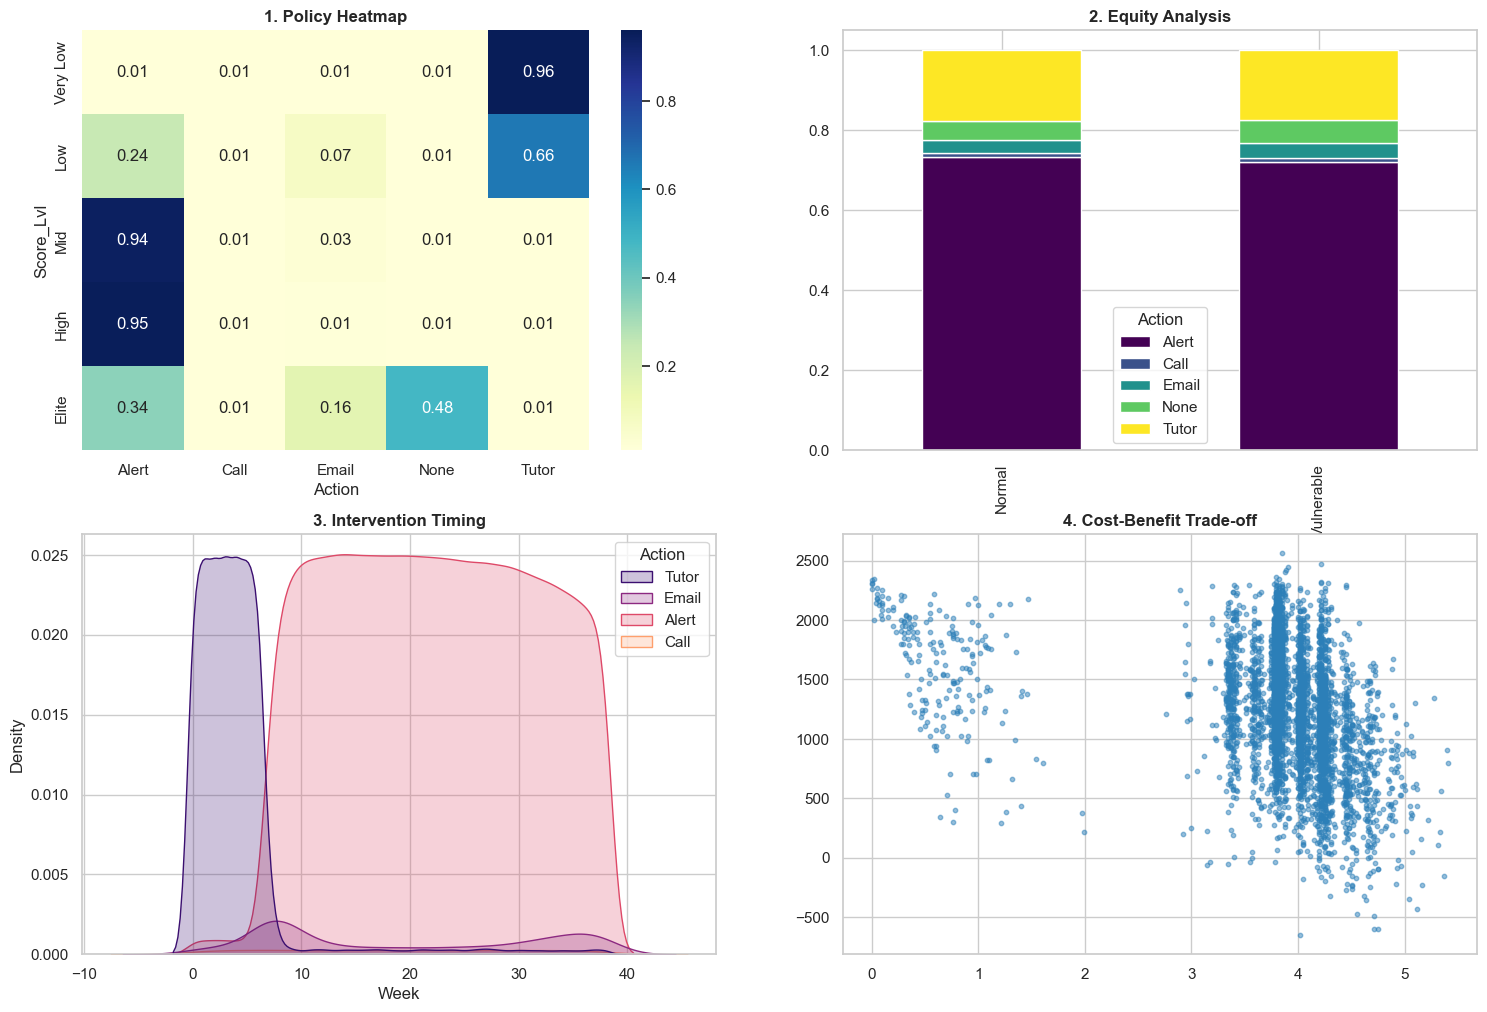


[SUCCESS] All results and Learning Curve generated.


In [11]:
# PART 4: EVALUATION PHASE & MULTI-DIMENSIONAL ANALYSIS

print("\n[PART 4] Starting Evaluation Phase...")

# Set Epsilon to 0.0 to disable exploration; agent now performs 100% exploitation 
# based on its learned optimal policy.
agent.epsilon = 0.05 

# Statistics container for performance, cost, equity, and timing metrics
stats = {'actions': [], 'costs': [], 'is_vul': [], 'scores': [], 'weeks': [], 'rewards': []}
act_map = {0: 'None', 1: 'Alert', 2: 'Email', 3: 'Call', 4: 'Tutor'}

# Sample 5000 random episodes to serve as a representative testing set
eval_ids = random.sample(list(student_groups.keys()), min(5000, len(student_groups)))

for i, pid in enumerate(eval_ids):
    env.student_data = student_groups[pid]
    state, _ = env.reset(pid)

    # Identify student demographic group for fairness/equity assessment
    is_vul = 'Vulnerable' if any(state[idx] == 1 for idx in env.vulnerable_indices) else 'Normal'
    done, ep_cost, ep_rew = False, 0, 0

    while not done:
        action = agent.act(state) # Select best action based on learned Q-values
        # Log weekly metrics to ensure data alignment for time-series visualization
        stats['actions'].append(act_map[action])
        stats['is_vul'].append(is_vul)
        stats['scores'].append(env.student_data.iloc[env.current_step]['score'])
        stats['weeks'].append(env.student_data.iloc[env.current_step]['week'])
        
        ep_cost += env.COSTS[action] # Accumulate operational costs
        state, reward, done, _, _ = env.step(action) # Transition to next week
        ep_rew += reward

    # Log per-episode aggregates for cost-benefit analysis
    stats['costs'].append(ep_cost)
    stats['rewards'].append(ep_rew)

# Action Summary Statistics 
# Generate a frequency distribution table of the agent's intervention choices
act_series = pd.Series(stats['actions'])
act_counts = act_series.value_counts().reindex(act_map.values()).fillna(0)
df_table = pd.DataFrame({
    'Action Type': act_counts.index,
    'Frequency': act_counts.values.astype(int),
    'Percentage (%)': (act_counts.values / len(act_series) * 100).round(2)
})
print("\n" + "="*40)
print("ACTION SUMMARY TABLE (OVERALL)")
print("="*40)
print(df_table.to_string(index=False))
print("="*40)

# Enhance Visual Analytics 
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
df_eval = pd.DataFrame({'Action': stats['actions'], 'Score': stats['scores'], 'Group': stats['is_vul'], 'Week': stats['weeks']})

# Bin continuous student scores into 5 categorical academic levels for clarity
df_eval['Score_Lvl'] = pd.cut(df_eval['Score'], bins=5, labels=['Very Low', 'Low', 'Mid', 'High', 'Elite'])

# 1. Policty Heatmap: Visualizes decision patterns relative to student performance
sns.heatmap(pd.crosstab(df_eval['Score_Lvl'], df_eval['Action'], normalize='index'), annot=True, cmap='YlGnBu', fmt='.2f', ax=axes[0,0])
axes[0,0].set_title('1. Policy Heatmap', fontweight='bold')

# 2. Equity Analysis: Visualizes resource distribution between demographic groups
pd.crosstab(df_eval['Group'], df_eval['Action'], normalize='index').plot(kind='bar', stacked=True, ax=axes[0,1], colormap='viridis')
axes[0,1].set_title('2. Equity Analysis', fontweight='bold')

# 3. Intervention Timing: Kernel Density Estimate (KDE) of intervention weeks
interv_df = df_eval[df_eval['Action'] != 'None']
if not interv_df.empty:
    sns.kdeplot(data=interv_df, x='Week', hue='Action', fill=True, ax=axes[1,0], palette='magma')
    axes[1,0].set_title('3. Intervention Timing', fontweight='bold')

# 4. Cost-benefit trade-off: Relationship between operational cost and cumulative reward
axes[1,1].scatter(stats['costs'], stats['rewards'], alpha=0.5, c='#2c7fb8', s=10)
axes[1,1].set_title('4. Cost-Benefit Trade-off', fontweight='bold')

plt.savefig('FINAL_THESIS_VISUALS.png', dpi=300)
plt.show()

print("\n[SUCCESS] All results and Learning Curve generated.")


[PART 5] Running Evaluation for 'After' Visualization...

[INFO] Generating 'After Intervention' Charts...

[INFO] Visualization saved as 'student_distribution_analysis.png'


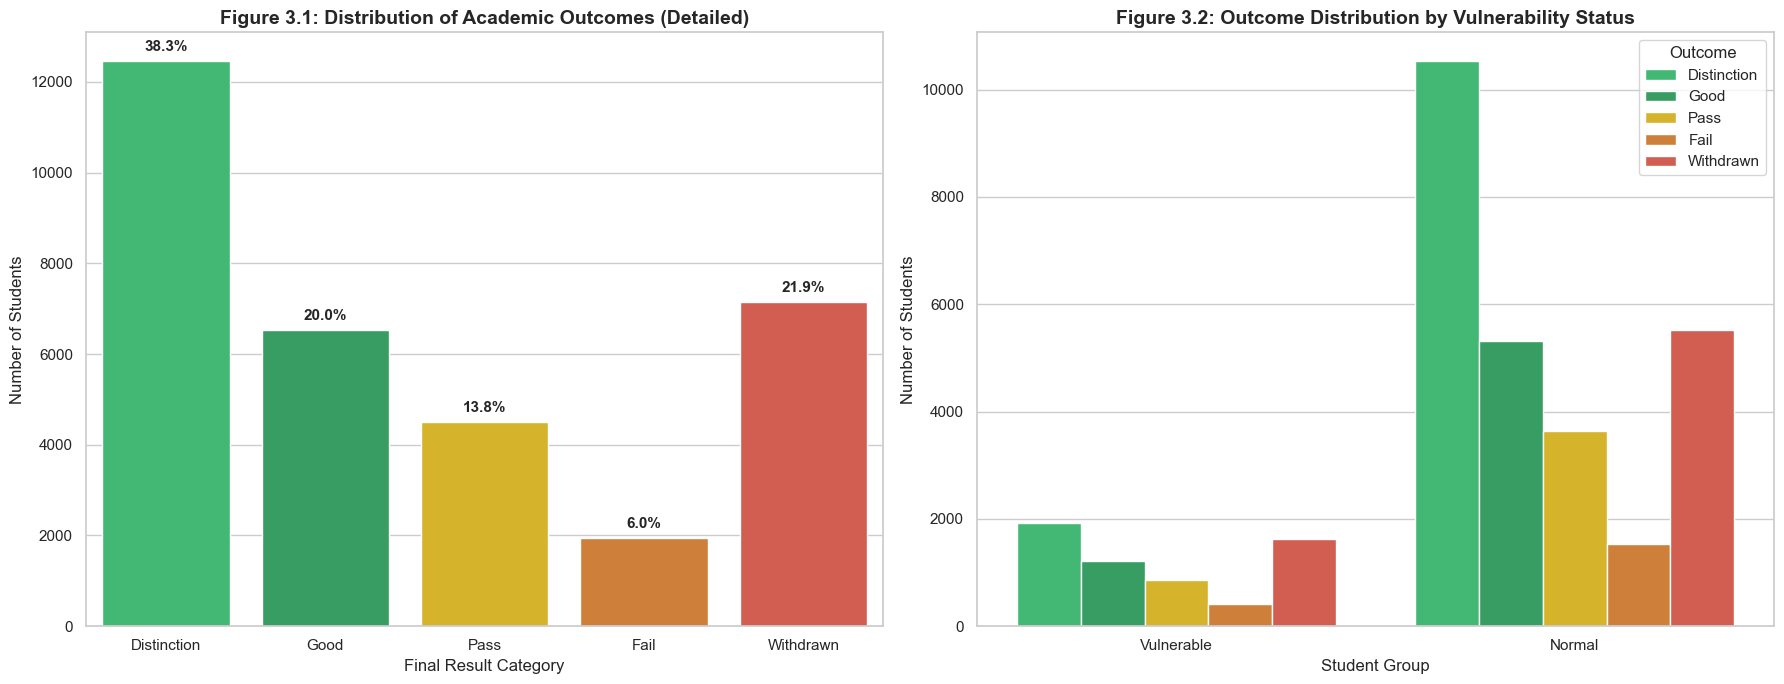

In [12]:
# PART 5: POST-INTERVENTION ANALYSIS & STUDENT SUCCESS VISUALIZATION

def evaluate_and_visualize_after(env, agent, test_ids):
    """
    Evaluate the agent's performance on a test set and visualize the outcomes.
    This captures the 'After Intervention' state for the thesis results.
    """
    after_intervention_data = []
    
    print("\n[PART 5] Running Evaluation for 'After' Visualization...")

    # Define the re-classification logic for terminal outcomes
    def re_classify(score):
        if score >= 0.75: return 'Distinction' # High achievers
        if score >= 0.60: return 'Good'        # Target for 'talent nurturing'
        if score >= 0.40: return 'Pass'        # Target for 'rescue' strategy
        if score < 0.10:  return 'Withdrawn'   # Students who dropped out
        return 'Fail'                          # Academic failure despite engagement

    # Set agent to pure exploitation (Epsilon = 0) for evaluation
    agent.epsilon = 0.0 
    
    for pid in test_ids:
        state, _ = env.reset(pid)
        done = False
        while not done:
            # Agent chooses the optimal intervention strategy
            action = agent.act(state) 
            state, reward, done, _, _ = env.step(action)
           
        # Extract the student's journey data
        final_student_state = env.student_data.copy()
        
        # Determine the final result based on the Week 39 score
        last_score = final_student_state.iloc[-1]['score']
        final_outcome = re_classify(last_score)
        
        # Assign the final outcome to the entire episode for consistent plotting
        final_student_state['detailed_result'] = final_outcome
        after_intervention_data.append(final_student_state)

    # Consolidate results for all test episodes
    master_df_after = pd.concat(after_intervention_data)
    
    print("\n[INFO] Generating 'After Intervention' Charts...")
    # This generates the final Figure 3.1 and 3.2 for the thesis document
    visualize_student_distribution(master_df_after)

# Evaluate on a subset to get immediate feedback
evaluate_and_visualize_after(env, agent, all_episode_ids)


[PART 6] Tracing Journey for Student: 678204_CCC_2014J...


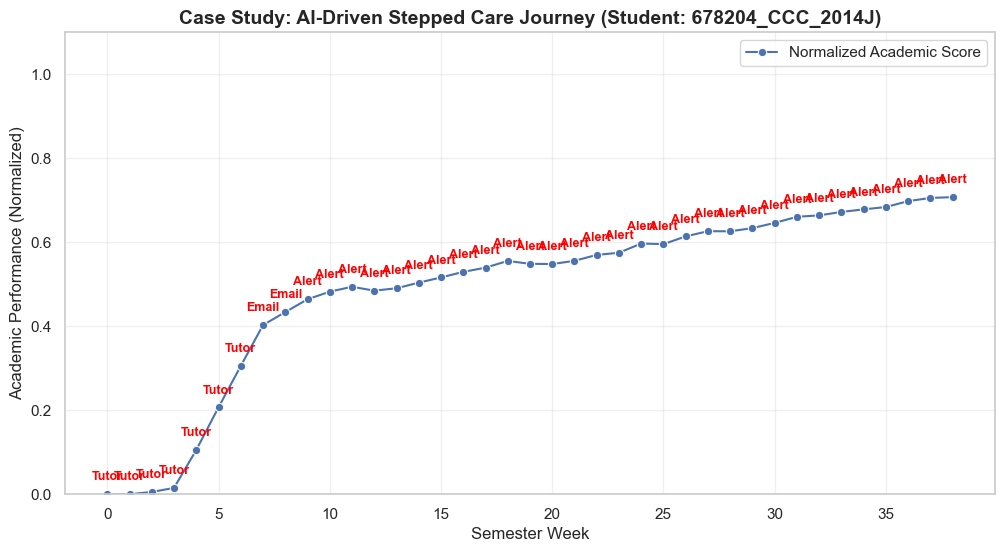

,Week,Score_Before,Intervention,Cost
0,0,0.000000,Tutor,0.45
1,1,0.000000,Tutor,0.45
2,2,0.005451,Tutor,0.45
3,3,0.015047,Tutor,0.45
4,4,0.105500,Tutor,0.45
5,5,0.206837,Tutor,0.45
6,6,0.305433,Tutor,0.45
7,7,0.402756,Email,0.05
8,8,0.433748,Email,0.05
9,9,0.464158,Alert,0.02


In [13]:
# PART 6: INDIVIDUAL CASE STUDY FOR QUALITATIVE ANALYSIS

def trace_student_journey(env, agent, student_id_to_trace):
    """
    Simulate and visualize the AI's decision-making process for a specific student.
    This provides a micro-level view of the intervention policy for the thesis discussion.
    """
    print(f"\n[PART 6] Tracing Journey for Student: {student_id_to_trace}...")
    
    # Switch to pure exploitation mode (deterministic policy)
    agent.epsilon = 0.0 
    state, _ = env.reset(student_id_to_trace)
    
    journey_log = []
    done = False
    
    while not done:
        # Capture current week and academic score before intervention
        current_week = env.student_data.iloc[env.current_step]['week']
        current_score = env.student_data.iloc[env.current_step]['score']
        
        # Agent selects the optimal action based on learned Q-values
        action = agent.act(state)
        action_name = act_map[action]
        
        # Log temporal data for longitudinal analysis
        journey_log.append({
            'Week': current_week,
            'Score_Before': current_score,
            'Intervention': action_name,
            'Cost': env.COSTS[action]
        })
        
        # Execute action and transition to the next state
        state, reward, done, _, _ = env.step(action)

    # Convert logs to DataFrame for visualization and statistical analysis
    df_journey = pd.DataFrame(journey_log)
    
    # VISUALIZATION: Academic Trajectory vs. AI Interventions
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_journey, x='Week', y='Score_Before', marker='o', label='Normalized Academic Score')
    
    # Annotate specific intervention points on the timeline
    for i, row in df_journey.iterrows():
        if row['Intervention'] != 'None':
            plt.annotate(row['Intervention'], 
                         (row['Week'], row['Score_Before']),
                         textcoords="offset points", 
                         xytext=(0,10), 
                         ha='center', 
                         fontsize=9,
                         fontweight='bold',
                         color='red')

    plt.title(f'Case Study: AI-Driven Stepped Care Journey (Student: {student_id_to_trace})', fontsize=14, fontweight='bold')
    plt.ylim(0, 1.1)
    plt.xlabel('Semester Week')
    plt.ylabel('Academic Performance (Normalized)')
    plt.grid(True, alpha=0.3)
    
    # Save the case study chart for Thesis Chapter 4 [cite: 58, 69]
    plt.savefig('student_case_study.png', dpi=300)
    plt.show()
    
    return df_journey

# Usage: Select a representative student from the evaluation set for qualitative analysis
sample_id = eval_ids[0] 
trace_student_journey(env, agent, sample_id)

In [ ]:
def _get_state(self):
    """
    Extracts and normalizes features from the student's current record 
    to create a state representation for the AI agent.
    """
    # Get the data row for the current academic week
    student_data = self.data.iloc[self.current_step]
    
    # Construct a 5-dimensional state vector
    state = np.array([
        student_data['score'],          # Normalized academic performance (0 to 1)
        student_data['click_count'],    # Weekly engagement volume in the VLE
        student_data['imd_band'],       # Socio-economic status (Index of Multiple Deprivation)
        student_data['disability'],     # Disability status (Fairness anchor)
        self.current_step / 40.0        # Temporal progress: week index normalized by course duration
    ], dtype=np.float32)
    
    return state

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class DQN(nn.Module):
    """
    Deep Q-Network architecture for educational intervention.
    Consists of an MLP with a bottleneck design for feature compression.
    """
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        # Input layer to first hidden layer (128 neurons)
        self.fc1 = nn.Linear(state_size, 128)
        # Second hidden layer (64 neurons) for abstract representation
        self.fc2 = nn.Linear(128, 64)
        # Output layer producing Q-values for the 5 Stepped Care actions
        self.fc3 = nn.Linear(64, action_size)

    def forward(self, x):
        # Non-linear activation using ReLU for efficient gradient flow
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        # Final layer outputs the estimated long-term reward for each action
        return self.fc3(x)

In [ ]:
def update_epsilon(self):
    """
    Reduces the exploration rate (epsilon) after each student episode.
    Ensures the agent transitions from trial-and-error to executing the learned policy.
    """
    # Check if the current epsilon is above the minimum threshold (0.05)
    if self.epsilon > self.epsilon_min:
        # Apply multiplicative decay factor (e.g., 0.9998)
        self.epsilon *= self.epsilon_decay
        
    # Maintain a floor for epsilon to allow for continuous adaptability
    self.epsilon = max(self.epsilon_min, self.epsilon)